In [1]:
import numpy as np
np.random.seed(42)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Set plotting style for formal aesthetic
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")
from sklearn.metrics import f1_score

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")


Libraries imported successfully.


In [ ]:
df=pd.read_csv('used_device_data.csv')
# Recompute the correct target
df["depreciation_ratio"] = np.exp(df["normalized_used_price"] - df["normalized_new_price"])

print(df["depreciation_ratio"].describe())

# to get a realistic estimate rather than one global average across all years/devices
df["rear_camera_mp"] = df.groupby(["device_brand", "release_year"])["rear_camera_mp"] \
    .transform(lambda x: x.fillna(x.median()))

## missing value treatement
# so fall back to a year-only group, then a global median as the last resort
df["rear_camera_mp"] = df.groupby("release_year")["rear_camera_mp"] \
    .transform(lambda x: x.fillna(x.median()))
df["rear_camera_mp"] = df["rear_camera_mp"].fillna(df["rear_camera_mp"].median())

def fill_with_fallback(df, col, group_cols_list):
    """Fill NaNs using progressively broader group medians, then a global median."""
    result = df[col].copy()
    for group_cols in group_cols_list:
        group_median = df.groupby(group_cols)[col].transform("median")
        result = result.fillna(group_median)
    result = result.fillna(df[col].median())
    return result

cols_to_fill = ["front_camera_mp", "internal_memory", "ram", "battery", "weight"]

for col in cols_to_fill:
    df[col] = fill_with_fallback(
        df, col,
        group_cols_list=[["device_brand", "release_year"], ["device_brand"], ["release_year"]]
    )

print(df[cols_to_fill].isnull().sum())

df.head()

count    3454.000000
mean        0.448815
std         0.161159
min         0.088455
25%         0.335865
50%         0.429273
75%         0.545084
max         0.984265
Name: depreciation_ratio, dtype: float64
front_camera_mp    0
internal_memory    0
ram                0
battery            0
weight             0
dtype: int64


,device_brand,os,screen_size,4g,5g,rear_camera_mp,front_camera_mp,internal_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price,depreciation_ratio
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.307572,4.715100,0.665293
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.162097,5.519018,0.699828
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.111084,5.884631,0.461374
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.135387,5.630961,0.609221
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.389995,4.947837,0.572443


In [3]:
df.shape

(3454, 16)

In [4]:
df['device_brand'].unique()

array(['Honor', 'Others', 'HTC', 'Huawei', 'Infinix', 'Lava', 'Lenovo',
       'LG', 'Meizu', 'Micromax', 'Motorola', 'Nokia', 'OnePlus', 'Oppo',
       'Realme', 'Samsung', 'Vivo', 'Xiaomi', 'ZTE', 'Apple', 'Asus',
       'Coolpad', 'Acer', 'Alcatel', 'BlackBerry', 'Celkon', 'Gionee',
       'Google', 'Karbonn', 'Microsoft', 'Panasonic', 'Sony', 'Spice',
       'XOLO'], dtype=object)

In [5]:
df.isna().sum()

,0
device_brand,0
os,0
screen_size,0
4g,0
5g,0
rear_camera_mp,0
front_camera_mp,0
internal_memory,0
ram,0
battery,0


In [ ]:
cols = ["front_camera_mp", "internal_memory", "ram", "battery", "weight"]
df[cols].isnull().sum(axis=1).value_counts()

,count
0,3454


In [ ]:
df['device_brand'].value_counts()

,count
device_brand,
Others,502
Samsung,341
Huawei,251
LG,201
Lenovo,171
ZTE,140
Xiaomi,132
Oppo,129
Asus,122


In [6]:
X=df.drop(['normalized_used_price','depreciation_ratio'],axis=1)

y=df['depreciation_ratio']
X.head()

,device_brand,os,screen_size,4g,5g,rear_camera_mp,front_camera_mp,internal_memory,ram,battery,weight,release_year,days_used,normalized_new_price
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.715100
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.519018
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.884631
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.630961
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.947837


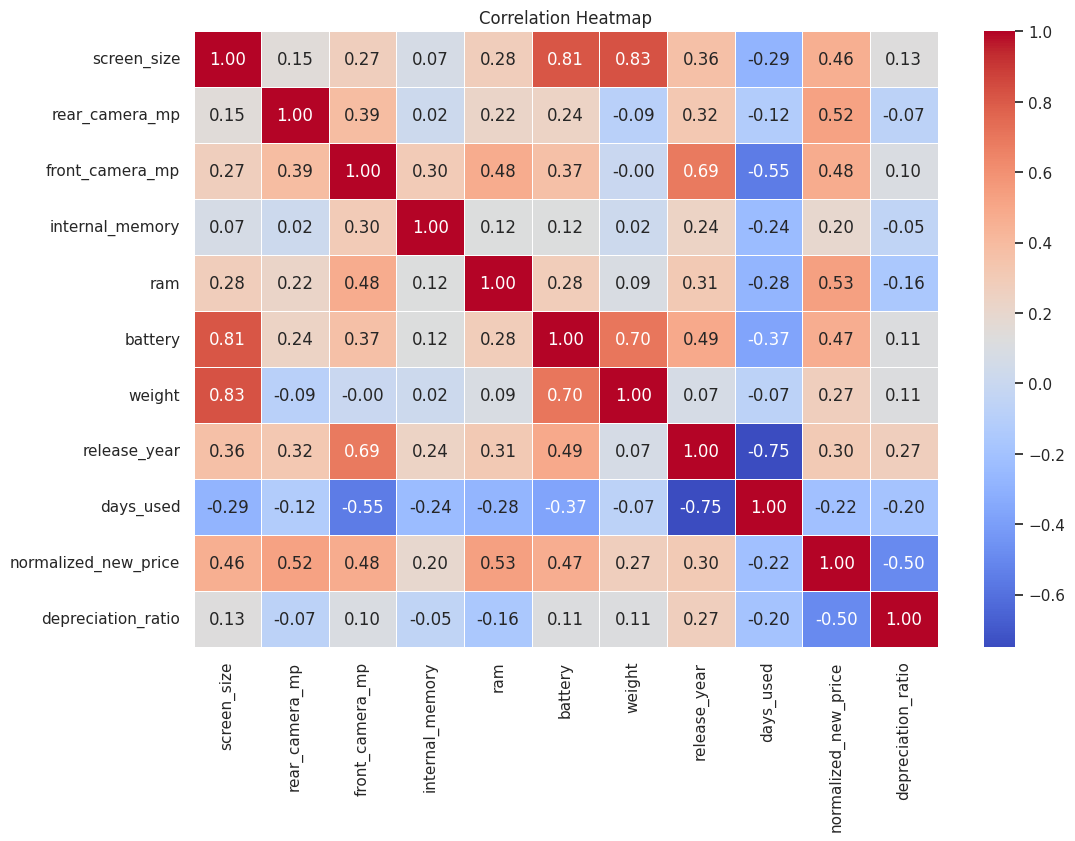

In [ ]:
dat=X.copy()
dat['depreciation_ratio']=y
corr = dat.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

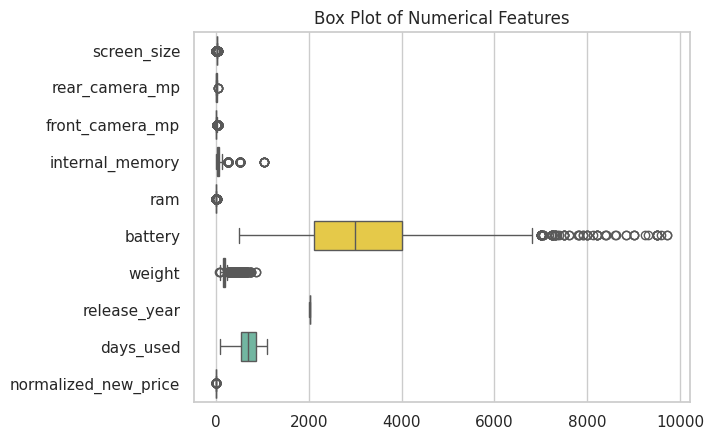

In [8]:
sns.boxplot(data=X, orient="h", palette="Set2")
plt.title("Box Plot of Numerical Features")
plt.show()

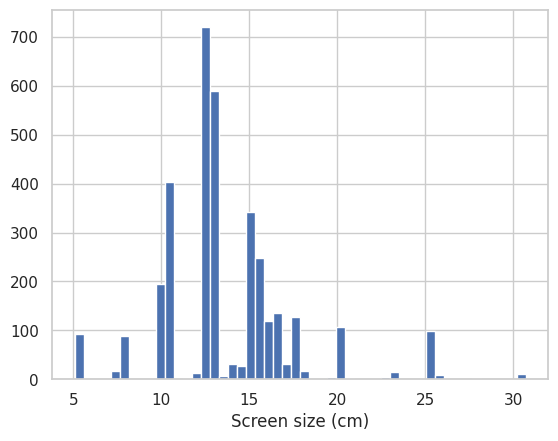

[np.float64(5.08), np.float64(5.13), np.float64(5.16), np.float64(5.18), np.float64(5.23), np.float64(5.28), np.float64(6.68), np.float64(7.62), np.float64(7.65), np.float64(7.67), np.float64(7.7), np.float64(7.75), np.float64(7.8), np.float64(7.82), np.float64(7.85), np.float64(7.98), np.float64(8.31), np.float64(10.03), np.float64(10.08), np.float64(10.16), np.float64(10.19), np.float64(10.21), np.float64(10.24), np.float64(10.29), np.float64(10.31), np.float64(10.34), np.float64(10.36), np.float64(11.48), np.float64(11.56), np.float64(11.76), np.float64(11.81), np.float64(11.84), np.float64(11.89), np.float64(12.12), np.float64(12.52), np.float64(12.57), np.float64(12.67), np.float64(12.7), np.float64(12.73), np.float64(12.75), np.float64(12.78), np.float64(12.8), np.float64(12.83), np.float64(12.85), np.float64(12.88), np.float64(12.9), np.float64(12.93), np.float64(13.08), np.float64(13.34), np.float64(13.56), np.float64(13.61), np.float64(13.79), np.float64(13.84), np.float64(13.

In [ ]:
import matplotlib.pyplot as plt
df["screen_size"].hist(bins=50)
plt.xlabel("Screen size (cm)")
plt.show()

print(sorted(df["screen_size"].unique()))

In [10]:
X.head()

,device_brand,os,screen_size,4g,5g,rear_camera_mp,front_camera_mp,internal_memory,ram,battery,weight,release_year,days_used,normalized_new_price
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.715100
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.519018
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.884631
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.630961
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.947837


In [ ]:
# Step 4: Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def preprocess_data(x):
    features=x.copy()
    features= pd.get_dummies(features, columns=["device_brand", "os"] ,dtype=int)
    features["4g"] = features["4g"].map({"yes": 1, "no": 0})
    features["5g"] = features["5g"].map({"yes": 1, "no": 0})
    features["is_tablet"] = (features["screen_size"] > 18.5).astype(int)
    # --- condition_score (1-10) ---
    days_used_norm = (features["days_used"] - features["days_used"].min()) / (features["days_used"].max() - features["days_used"].min())

    base_condition = 10 - (days_used_norm * 6)   # ranges ~4 to 10 before noise

    # Add random noise to simulate real-world variability in how people treat their devices
    noise = np.random.normal(loc=0, scale=1.3, size=len(features))

    features["condition_score"] = (base_condition + noise).clip(1, 10).round().astype(int)

    # --- working (1 = working, 0 = not working) ---
    # Failure probability rises with age, and also with very low condition_score
    # (a badly-worn phone is more likely to have functional issues too)
    base_fail_prob = 0.02 + (days_used_norm * 0.06)                       
    condition_penalty = np.where(features["condition_score"] <= 3, 0.15, 0.0)   
    fail_prob = (base_fail_prob + condition_penalty).clip(0, 0.5)

    features["working"] = (np.random.rand(len(features)) > fail_prob).astype(int)

    print(features["condition_score"].value_counts().sort_index())
    print(features["working"].value_counts(normalize=True))
    return features

x=X.copy()
x=preprocess_data(x)

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Processed feature matrix shape (numeric only): {X.shape}")


condition_score
1       4
2      32
3     168
4     332
5     521
6     665
7     686
8     483
9     299
10    264
Name: count, dtype: int64
working
1    0.93949
0    0.06051
Name: proportion, dtype: float64
Processed feature matrix shape (numeric only): (3454, 14)


In [ ]:
from sklearn.linear_model import RidgeCV, LassoCV

ridge_cv = RidgeCV(alphas=np.logspace(-4, 3, 100), cv=5).fit(X_train_scaled, y_train)
lasso_cv = LassoCV(alphas=np.logspace(-4, 3, 100), cv=5, random_state=42).fit(X_train_scaled, y_train)

print(f"Optimal Alpha for Ridge: {ridge_cv.alpha_:.4f}")
print(f"Optimal Alpha for Lasso: {lasso_cv.alpha_:.4f}")

Optimal Alpha for Ridge: 17.0735
Optimal Alpha for Lasso: 0.0011


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=17.0735),    
    'Lasso': Lasso(alpha=0.0011)      
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    preds = model.predict(X_test_scaled)
    predictions[name] = preds

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        'Model': name,
        'MAE ($)': mae,
        'RMSE ($)': rmse,
        'R² Score': r2
    })

df_results = pd.DataFrame(results).set_index('Model')
print("--- Model Performance Comparison ---")
print(df_results)

--- Model Performance Comparison ---
                    MAE ($)  RMSE ($)  R² Score
Model                                          
Linear Regression  0.079359  0.099361  0.617661
Ridge              0.079442  0.099379  0.617517
Lasso              0.079431  0.098893  0.621251


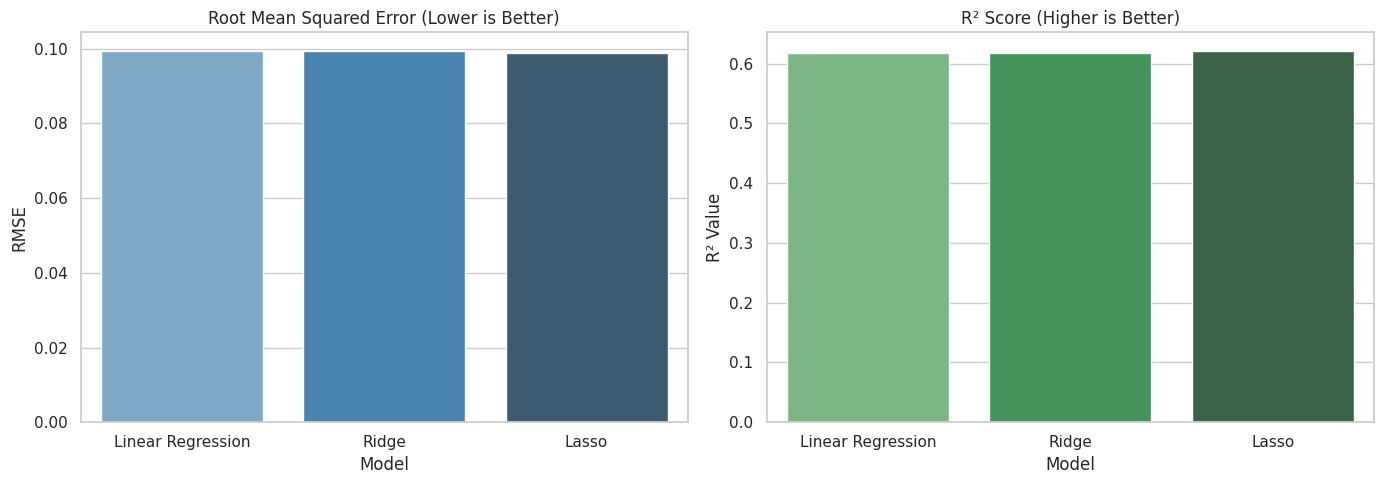

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=df_results.index, y=df_results['RMSE ($)'], ax=axes[0], palette='Blues_d')
axes[0].set_title('Root Mean Squared Error (Lower is Better)', fontsize=12)
axes[0].set_ylabel('RMSE')

sns.barplot(x=df_results.index, y=df_results['R² Score'], ax=axes[1], palette='Greens_d')
axes[1].set_title('R² Score (Higher is Better)', fontsize=12)
axes[1].set_ylabel('R² Value')

plt.tight_layout()
plt.show()

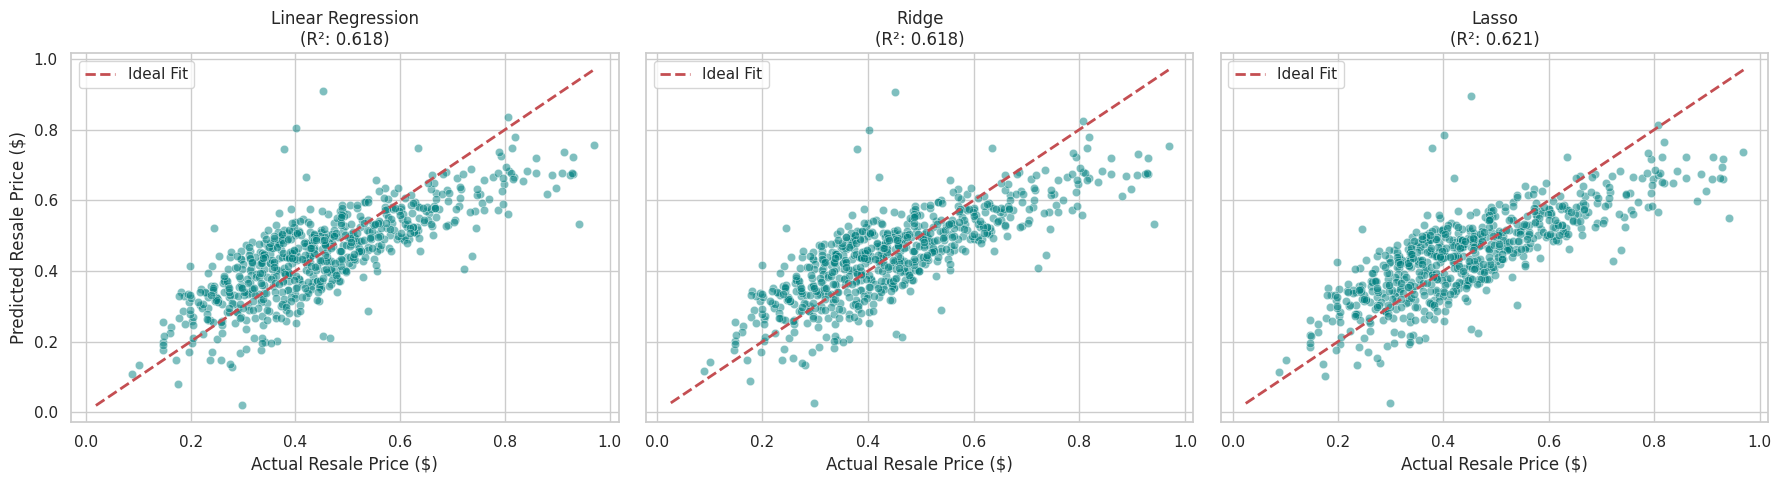

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, (name, preds) in enumerate(predictions.items()):
    ax = axes[i]
    sns.scatterplot(x=y_test, y=preds, ax=ax, alpha=0.5, color='teal')

    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal Fit')

    r2 = df_results.loc[name, 'R² Score']
    ax.set_title(f'{name}\n(R²: {r2:.3f})', fontsize=12)
    ax.set_xlabel('Actual Resale Price ($)')
    if i == 0:
        ax.set_ylabel('Predicted Resale Price ($)')
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.dummy import DummyRegressor
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
dummy_preds = dummy.predict(X_test)
print("Dummy MAE:", mean_absolute_error(y_test, dummy_preds))
print("Dummy R²:", r2_score(y_test, dummy_preds))  

Dummy MAE: 0.1268485999628479
Dummy R²: -6.805094160977632e-05


In [12]:
x_copy=X.copy()
x_copy=preprocess_data(x_copy)
x_copy.head()

condition_score
1       7
2      47
3     156
4     346
5     576
6     631
7     625
8     470
9     341
10    255
Name: count, dtype: int64
working
1    0.933121
0    0.066879
Name: proportion, dtype: float64


,screen_size,4g,5g,rear_camera_mp,front_camera_mp,internal_memory,ram,battery,weight,release_year,...,device_brand_XOLO,device_brand_Xiaomi,device_brand_ZTE,os_Android,os_Others,os_Windows,os_iOS,is_tablet,condition_score,working
0,14.50,1,0,13.0,5.0,64.0,3.0,3020.0,146.0,2020,...,0,0,0,1,0,0,0,0,9,1
1,17.30,1,1,13.0,16.0,128.0,8.0,4300.0,213.0,2020,...,0,0,0,1,0,0,0,0,9,1
2,16.69,1,1,13.0,8.0,128.0,8.0,4200.0,213.0,2020,...,0,0,0,1,0,0,0,0,9,1
3,25.50,1,1,13.0,8.0,64.0,6.0,7250.0,480.0,2020,...,0,0,0,1,0,0,0,1,7,1
4,15.32,1,0,13.0,8.0,64.0,3.0,5000.0,185.0,2020,...,0,0,0,1,0,0,0,0,9,1


In [ ]:
x_copy.columns

Index(['screen_size', '4g', '5g', 'rear_camera_mp', 'front_camera_mp',
       'internal_memory', 'ram', 'battery', 'weight', 'release_year',
       'days_used', 'device_brand_Acer', 'device_brand_Alcatel',
       'device_brand_Apple', 'device_brand_Asus', 'device_brand_BlackBerry',
       'device_brand_Celkon', 'device_brand_Coolpad', 'device_brand_Gionee',
       'device_brand_Google', 'device_brand_HTC', 'device_brand_Honor',
       'device_brand_Huawei', 'device_brand_Infinix', 'device_brand_Karbonn',
       'device_brand_LG', 'device_brand_Lava', 'device_brand_Lenovo',
       'device_brand_Meizu', 'device_brand_Micromax', 'device_brand_Microsoft',
       'device_brand_Motorola', 'device_brand_Nokia', 'device_brand_OnePlus',
       'device_brand_Oppo', 'device_brand_Others', 'device_brand_Panasonic',
       'device_brand_Realme', 'device_brand_Samsung', 'device_brand_Sony',
       'device_brand_Spice', 'device_brand_Vivo', 'device_brand_XOLO',
       'device_brand_Xiaomi', 'device_b

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


tree_models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
}

tree_results = []
tree_predictions = {}

for name, model in tree_models.items():
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    tree_predictions[name] = preds

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    tree_results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R² Score': r2
    })

df_tree_results = pd.DataFrame(tree_results).set_index('Model')
print("--- Tree Models Performance Comparison ---")
print(df_tree_results)

--- Tree Models Performance Comparison ---
                    MAE      RMSE  R² Score
Model                                      
Random Forest  0.072426  0.089208  0.691808
XGBoost        0.072087  0.088995  0.693274


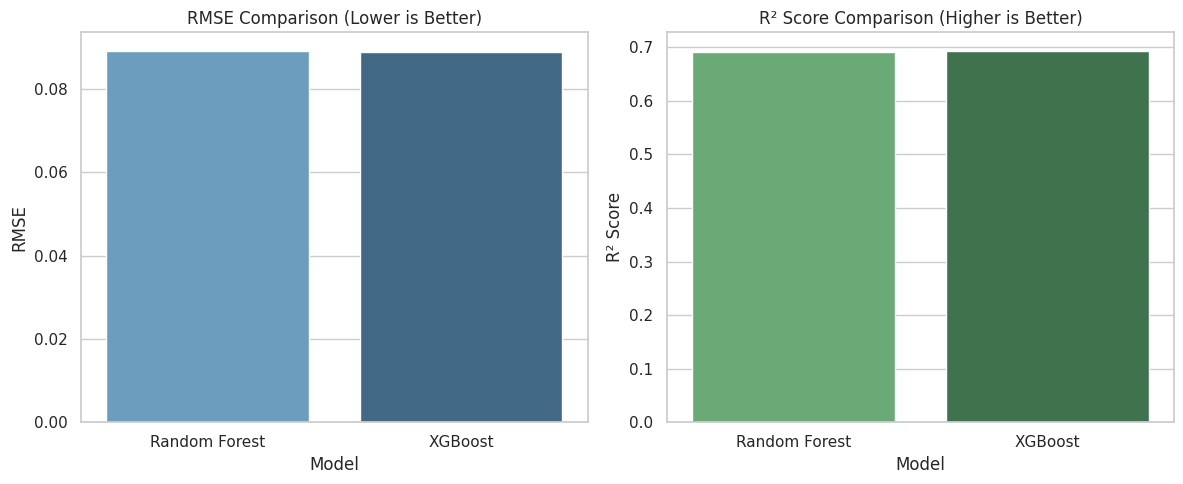

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=df_tree_results.index, y=df_tree_results['RMSE'], ax=axes[0], palette='Blues_d')
axes[0].set_title('RMSE Comparison (Lower is Better)', fontsize=12)
axes[0].set_ylabel('RMSE')

sns.barplot(x=df_tree_results.index, y=df_tree_results['R² Score'], ax=axes[1], palette='Greens_d')
axes[1].set_title('R² Score Comparison (Higher is Better)', fontsize=12)
axes[1].set_ylabel('R² Score')

plt.tight_layout()
plt.show()

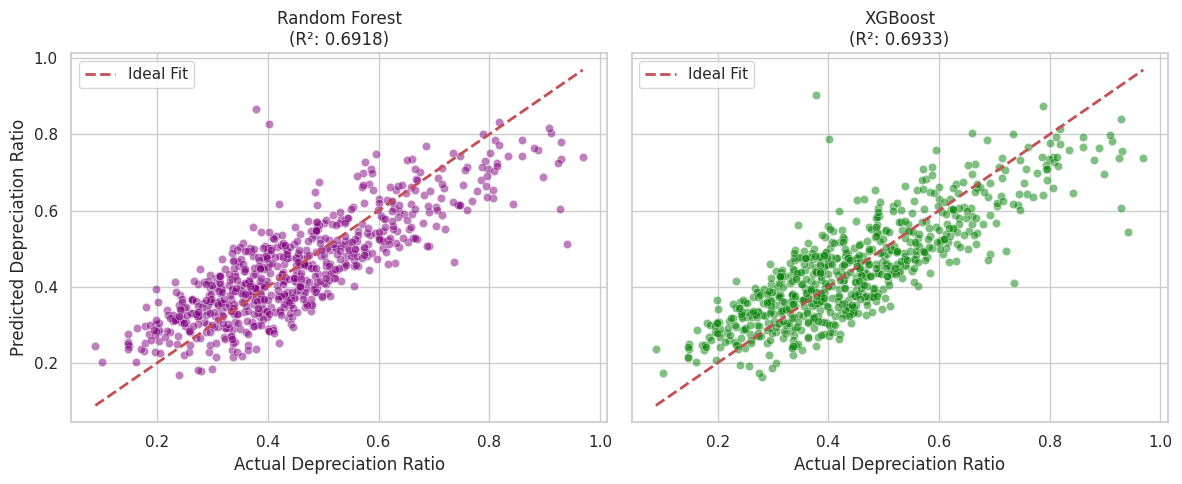

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, (name, preds) in enumerate(tree_predictions.items()):
    ax = axes[i]
    sns.scatterplot(x=y_test, y=preds, ax=ax, alpha=0.5, color='purple' if i==0 else 'green')

    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal Fit')

    r2 = df_tree_results.loc[name, 'R² Score']
    ax.set_title(f'{name}\n(R²: {r2:.4f})', fontsize=12)
    ax.set_xlabel('Actual Depreciation Ratio')
    if i == 0:
        ax.set_ylabel('Predicted Depreciation Ratio')
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

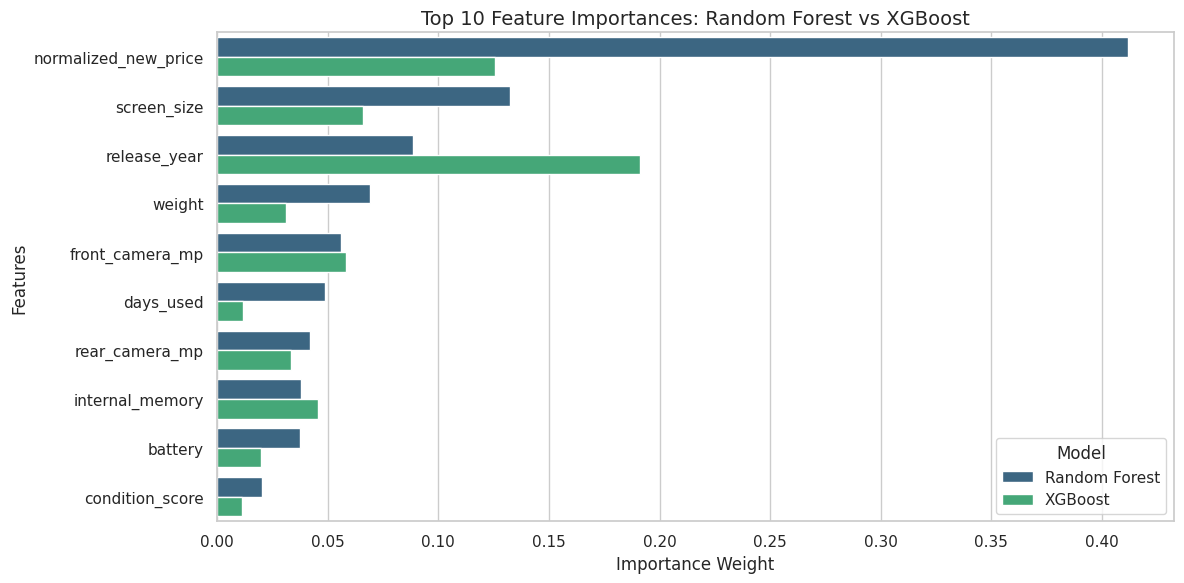

In [ ]:
importance_df = pd.DataFrame({'Feature': X_train.columns})

for name, model in tree_models.items():
    importance_df[name] = model.feature_importances_

top_10_features = importance_df.sort_values(by='Random Forest', ascending=False).head(10)

top_10_melted = top_10_features.melt(id_vars='Feature', var_name='Model', value_name='Importance')

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_melted, x='Importance', y='Feature', hue='Model', palette='viridis')
plt.title('Top 10 Feature Importances: Random Forest vs XGBoost', fontsize=14)
plt.xlabel('Importance Weight')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rf_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 15, 20, 25],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5, 0.8]  # Helps with sparse brand columns
}

xgb_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.4, 0.6, 0.7, 0.8, 1.0],  # CRUCIAL for 40+ one-hot brand columns!
    'reg_alpha': [0, 0.01, 0.1, 1, 10],            # L1 Regularization
    'reg_lambda': [0.1, 1, 5, 10]                  # L2 Regularization
}

print(" Searching best parameters for Random Forest...")

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_grid,
    n_iter=20,            
    scoring='r2',         
    cv=5,                
    random_state=42,
    n_jobs=-1,            
    verbose=1
)

rf_search.fit(X_train, y_train)

print("\n Searching best parameters for XGBoost...")

xgb_base = XGBRegressor(random_state=42, n_jobs=-1)

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=30,           
    scoring='r2',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_
best_xgb = xgb_search.best_estimator_

rf_tuned_preds = best_rf.predict(X_test)
xgb_tuned_preds = best_xgb.predict(X_test)


tuned_results = [
    {
        'Model': 'Tuned Random Forest',
        'MAE': mean_absolute_error(y_test, rf_tuned_preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, rf_tuned_preds)),
        'R² Score': r2_score(y_test, rf_tuned_preds)
    },
    {
        'Model': 'Tuned XGBoost',
        'MAE': mean_absolute_error(y_test, xgb_tuned_preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, xgb_tuned_preds)),
        'R² Score': r2_score(y_test, xgb_tuned_preds)
    }
]

df_tuned = pd.DataFrame(tuned_results).set_index('Model')

print("\n================ FINAL COMPARISON ================")
print(df_tuned)

print("\n Best Random Forest Parameters:")
print(rf_search.best_params_)

print("\n Best XGBoost Parameters:")
print(xgb_search.best_params_)

 Searching best parameters for Random Forest...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

 Searching best parameters for XGBoost...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

================ FINAL COMPARISON ================
                          MAE      RMSE  R² Score
Model                                            
Tuned Random Forest  0.072890  0.089453  0.690109
Tuned XGBoost        0.071007  0.087274  0.705025

🏆 Best Random Forest Parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': None}

🏆 Best XGBoost Parameters:
{'subsample': 0.9, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


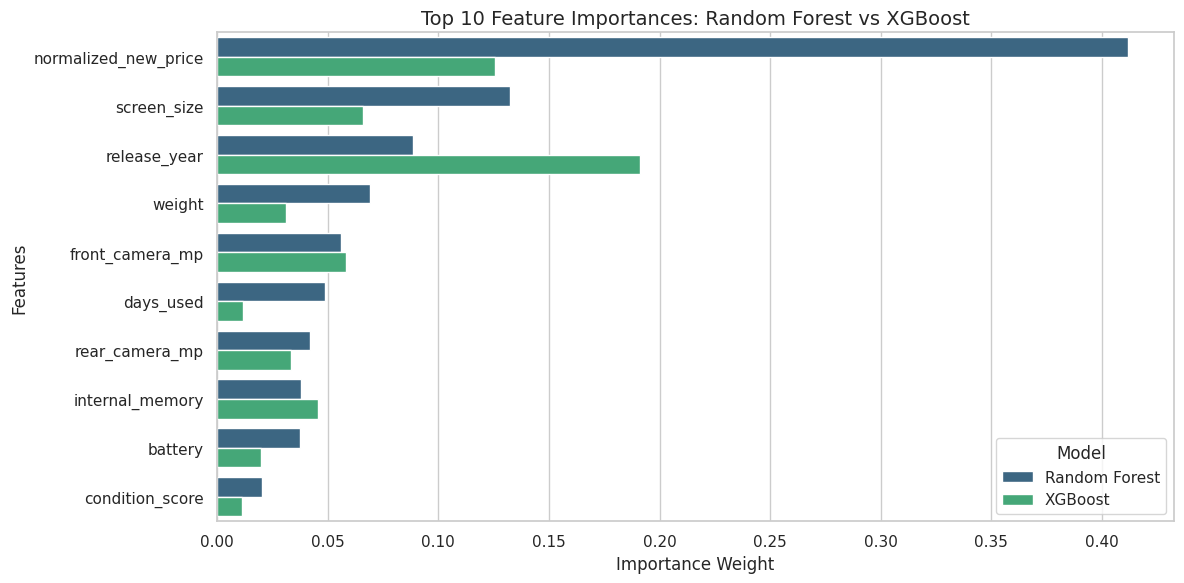

In [ ]:
importance_df = pd.DataFrame({'Feature': X_train.columns})

for name, model in tree_models.items():
    importance_df[name] = model.feature_importances_

top_10_features = importance_df.sort_values(by='Random Forest', ascending=False).head(10)

top_10_melted = top_10_features.melt(id_vars='Feature', var_name='Model', value_name='Importance')

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_melted, x='Importance', y='Feature', hue='Model', palette='viridis')
plt.title('Top 10 Feature Importances: Random Forest vs XGBoost', fontsize=14)
plt.xlabel('Importance Weight')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [15]:
X=preprocess_data(X)
X.head()

condition_score
1       7
2      54
3     118
4     358
5     538
6     679
7     619
8     509
9     337
10    235
Name: count, dtype: int64
working
1    0.938043
0    0.061957
Name: proportion, dtype: float64


,screen_size,4g,5g,rear_camera_mp,front_camera_mp,internal_memory,ram,battery,weight,release_year,...,device_brand_XOLO,device_brand_Xiaomi,device_brand_ZTE,os_Android,os_Others,os_Windows,os_iOS,is_tablet,condition_score,working
0,14.50,1,0,13.0,5.0,64.0,3.0,3020.0,146.0,2020,...,0,0,0,1,0,0,0,0,7,1
1,17.30,1,1,13.0,16.0,128.0,8.0,4300.0,213.0,2020,...,0,0,0,1,0,0,0,0,8,1
2,16.69,1,1,13.0,8.0,128.0,8.0,4200.0,213.0,2020,...,0,0,0,1,0,0,0,0,10,1
3,25.50,1,1,13.0,8.0,64.0,6.0,7250.0,480.0,2020,...,0,0,0,1,0,0,0,1,9,1
4,15.32,1,0,13.0,8.0,64.0,3.0,5000.0,185.0,2020,...,0,0,0,1,0,0,0,0,8,1
